# LE2 Daten bereinigen

In LE2 prüfen wir die Datenqualität und bauen Cleaning Funktionen.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from myproj.io.import_data import load_raw_data

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)

## Daten laden

Rohdaten werden mit der bestehenden Import Funktion geladen.

In [27]:
emdat = load_raw_data("public_emdat_1991_2024.xlsx")
sea_level = load_raw_data("omi_climate_sl_medsea_area_averaged_anomalies_19990220_P20250729.nc")

sea_level_df = sea_level.to_dataframe().reset_index()

dataset_overview = pd.DataFrame(
    {
        "rows": [len(emdat), len(sea_level_df)],
        "cols": [emdat.shape[1], sea_level_df.shape[1]],
    },
    index=["emdat", "sea_level_df"],
)

display(dataset_overview)

,rows,cols
emdat,20657,47
sea_level_df,9405,3


## Relevante Spalten

Wir nutzen nur die definierten EMDAT Spalten für Zeit, Klassifikation, Ort und Impact. `DisNo.` wird als eindeutige Katastrophen-ID mitgeführt. Die Key Spalten (ohne Impact-Felder und ohne `DisNo.`) beschreiben die zeitlich-räumliche Identität eines Ereignisses.

In [28]:
emdat_relevant_cols_target = [
    "DisNo.",
    "Start Year",
    "Start Month",
    "Start Day",
    "End Year",
    "End Month",
    "End Day",
    "Disaster Type",
    "Disaster Subtype",
    "Country",
    "Region",
    "Latitude",
    "Longitude",
    "Total Affected",
    "Total Deaths",
]

emdat_relevant_cols = [c for c in emdat_relevant_cols_target if c in emdat.columns]

emdat_key_cols_target = [
    "Start Year",
    "Start Month",
    "Start Day",
    "End Year",
    "End Month",
    "End Day",
    "Disaster Type",
    "Disaster Subtype",
    "Country",
    "Region",
    "Latitude",
    "Longitude",
]

emdat_key_cols = [c for c in emdat_key_cols_target if c in emdat.columns]

emdat_focus = emdat[emdat_relevant_cols].copy()

emdat_relevant_numeric = [
    c for c in emdat_relevant_cols if pd.api.types.is_numeric_dtype(emdat[c])
]
emdat_relevant_categorical = [c for c in emdat_relevant_cols if c not in emdat_relevant_numeric]

sea_level_time_cols = [c for c in sea_level_df.columns if "time" in c.lower()]
sea_level_value_cols = sea_level_df.select_dtypes(include="number").columns.tolist()
sea_level_relevant_cols = sea_level_df.columns.tolist()
sea_level_focus = (
    sea_level_df[sea_level_relevant_cols].copy()
    if sea_level_relevant_cols
    else sea_level_df.copy()
)

display(pd.Series(emdat_relevant_cols, name="emdat_relevant_cols"))
display(pd.Series(sea_level_relevant_cols, name="sea_level_relevant_cols"))

0               DisNo.
1           Start Year
2          Start Month
3            Start Day
4             End Year
5            End Month
6              End Day
7        Disaster Type
8     Disaster Subtype
9              Country
10              Region
11            Latitude
12           Longitude
13      Total Affected
14        Total Deaths
Name: emdat_relevant_cols, dtype: str

0                                         time
1          MSL_filtered_GIA_corrected_adjusted
2    trend_MSL_filtered_GIA_corrected_adjusted
Name: sea_level_relevant_cols, dtype: str

### EMDAT Überblick
Wir sehen Umfang und einen kleinen Ausschnitt der relevanten Spalten.

In [29]:
emdat_overview = pd.DataFrame(
    {
        "rows": [len(emdat)],
        "cols": [emdat.shape[1]],
        "focus_cols": [len(emdat_relevant_cols)],
    },
    index=["emdat"],
)

display(emdat_overview)
display(emdat_focus.head(3))

,rows,cols,focus_cols
emdat,20657,47,15


,DisNo.,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Latitude,Longitude,Total Affected,Total Deaths
0,2018-0040-BRA,2018,2.0,14.0,2018,2.0,16.0,Flood,Flood (General),Brazil,Americas,-22.479,-44.095,250.0,4.0
1,2002-0351-USA,2002,6.0,8.0,2002,6.0,8.0,Wildfire,Forest fire,United States of America,Americas,NaN,NaN,1572.0,NaN
2,1990-9604-BWA,1992,NaN,NaN,1992,NaN,NaN,Drought,Drought,Botswana,Africa,NaN,NaN,100000.0,NaN


### EMDAT Missing values
Wir prüfen Missing values in den relevanten Spalten.

In [30]:
def missingness_summary(df, cols):
    if not cols:
        return pd.DataFrame()
    m = df[cols].isna().sum()
    m = m[m > 0].sort_values(ascending=False)
    if m.empty:
        return pd.DataFrame()
    return pd.DataFrame({"missing": m, "pct": (m / len(df) * 100).round(2)})

In [31]:
emdat_missing = missingness_summary(emdat_focus, emdat_relevant_cols)
if emdat_missing.empty:
    display(pd.DataFrame({"info": ["Keine Missing values in den relevanten Spalten"]}))
else:
    display(emdat_missing)

,missing,pct
Latitude,18571,89.90
Longitude,18571,89.90
Total Affected,5648,27.34
Total Deaths,4030,19.51
Start Day,2149,10.40
End Day,2048,9.91
End Month,278,1.35
Start Month,114,0.55


In [ ]:
month_missing_start = emdat_focus["Start Month"].isna() if "Start Month" in emdat_focus.columns else pd.Series(False, index=emdat_focus.index)
month_missing_end = emdat_focus["End Month"].isna() if "End Month" in emdat_focus.columns else pd.Series(False, index=emdat_focus.index)

type_text = emdat_focus.get("Disaster Type", pd.Series("", index=emdat_focus.index)).fillna("").astype(str)
subtype_text = emdat_focus.get("Disaster Subtype", pd.Series("", index=emdat_focus.index)).fillna("").astype(str)

water_flood_mask = (
    type_text.str.contains(r"flood|water", case=False, regex=True)
    | subtype_text.str.contains(r"flood|water", case=False, regex=True)
)

post1999_mask = emdat_focus["Start Year"] >= 1999

summary = pd.DataFrame(
    {
        "subset": [
            "Missing Start Month",
            "Missing End Month",
            "Water/Flood + Missing Start Month",
            "Water/Flood + Missing End Month",
            "Water/Flood + Missing Start Month + Start Year >= 1999",
            "Water/Flood + Missing End Month + Start Year >= 1999",
        ],
        "count": [
            int(month_missing_start.sum()),
            int(month_missing_end.sum()),
            int((water_flood_mask & month_missing_start).sum()),
            int((water_flood_mask & month_missing_end).sum()),
            int((water_flood_mask & month_missing_start & post1999_mask).sum()),
            int((water_flood_mask & month_missing_end & post1999_mask).sum()),
        ],
    }
)

display(summary)

cols_show = [
    c for c in [
        "Start Year", "Start Month", "Start Day",
        "End Year", "End Month", "End Day",
        "Disaster Type", "Disaster Subtype",
        "Country", "Region",
        "Total Affected", "Total Deaths"
    ] if c in emdat_focus.columns
]

display(
    emdat_focus.loc[water_flood_mask & month_missing_start, cols_show]
    .sort_values(["Start Year", "Country"], na_position="last")
    .head(20)
)

display(
    emdat_focus.loc[water_flood_mask & month_missing_end, cols_show]
    .sort_values(["Start Year", "Country"], na_position="last")
    .head(20)
)

display(
    emdat_focus.loc[water_flood_mask & month_missing_start & post1999_mask, cols_show]
    .sort_values(["Start Year", "Country"], na_position="last")
)

display(
    emdat_focus.loc[water_flood_mask & month_missing_end & post1999_mask, cols_show]
    .sort_values(["Start Year", "Country"], na_position="last")
)

,subset,count
0,Missing Start Month,114
1,Missing End Month,278
2,Water/Flood + Missing Start Month,4
3,Water/Flood + Missing End Month,4
4,Water/Flood + Missing Start Month + Start Year...,1
5,Water/Flood + Missing End Month + Start Year >...,1


,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Total Affected,Total Deaths
182,1991,NaN,NaN,1991,NaN,NaN,Water,Water,China,Asia,NaN,54.0
1645,1994,NaN,NaN,1994,NaN,NaN,Flood,Flood (General),Burkina Faso,Africa,66500.0,22.0
3284,1998,NaN,NaN,1998,NaN,NaN,Flood,Flood (General),Brazil,Americas,32000.0,3.0
18668,2014,NaN,NaN,2014,5.0,NaN,Flood,Riverine flood,Zambia,Africa,20000.0,NaN


,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Total Affected,Total Deaths
182,1991,NaN,NaN,1991,NaN,NaN,Water,Water,China,Asia,NaN,54.0
1645,1994,NaN,NaN,1994,NaN,NaN,Flood,Flood (General),Burkina Faso,Africa,66500.0,22.0
3284,1998,NaN,NaN,1998,NaN,NaN,Flood,Flood (General),Brazil,Americas,32000.0,3.0
12657,2023,10.0,15.0,2024,NaN,NaN,Flood,Flood (General),Kenya,Africa,695497.0,178.0


,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Total Affected,Total Deaths
18668,2014,NaN,NaN,2014,5.0,NaN,Flood,Riverine flood,Zambia,Africa,20000.0,NaN


,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Total Affected,Total Deaths
12657,2023,10.0,15.0,2024,NaN,NaN,Flood,Flood (General),Kenya,Africa,695497.0,178.0


In [50]:
day_missing_start = emdat_focus["Start Day"].isna() if "Start Day" in emdat_focus.columns else pd.Series(False, index=emdat_focus.index)
day_missing_end = emdat_focus["End Day"].isna() if "End Day" in emdat_focus.columns else pd.Series(False, index=emdat_focus.index)

type_text = emdat_focus.get("Disaster Type", pd.Series("", index=emdat_focus.index)).fillna("").astype(str)
subtype_text = emdat_focus.get("Disaster Subtype", pd.Series("", index=emdat_focus.index)).fillna("").astype(str)

water_flood_mask = (
    type_text.str.contains(r"flood|water", case=False, regex=True)
    | subtype_text.str.contains(r"flood|water", case=False, regex=True)
)

post1999_mask = emdat_focus["Start Year"] >= 1999

summary = pd.DataFrame(
    {
        "subset": [
            "Missing Start Day",
            "Missing End Day",
            "Water/Flood + Missing Start Day",
            "Water/Flood + Missing End Day",
            "Water/Flood + Missing Start Day + Start Year >= 1999",
            "Water/Flood + Missing End Day + Start Year >= 1999",
        ],
        "count": [
            int(day_missing_start.sum()),
            int(day_missing_end.sum()),
            int((water_flood_mask & day_missing_start).sum()),
            int((water_flood_mask & day_missing_end).sum()),
            int((water_flood_mask & day_missing_start & post1999_mask).sum()),
            int((water_flood_mask & day_missing_end & post1999_mask).sum()),
        ],
    }
)

display(summary)

cols_show = [
    c for c in [
        "Start Year", "Start Month", "Start Day",
        "End Year", "End Month", "End Day",
        "Disaster Type", "Disaster Subtype",
        "Country", "Region",
        "Total Affected", "Total Deaths"
    ] if c in emdat_focus.columns
]

display(
    emdat_focus.loc[water_flood_mask & day_missing_start, cols_show]
    .sort_values(["Start Year", "Country"], na_position="last")
    .head(10)
)

display(
    emdat_focus.loc[water_flood_mask & day_missing_end, cols_show]
    .sort_values(["Start Year", "Country"], na_position="last")
    .head(10)
)

display(
    emdat_focus.loc[water_flood_mask & day_missing_start & post1999_mask, cols_show]
    .sort_values(["Start Year", "Country"], na_position="last")
    .head(10)
)

display(
    emdat_focus.loc[water_flood_mask & day_missing_end & post1999_mask, cols_show]
    .sort_values(["Start Year", "Country"], na_position="last")
    .head(10)
)


,subset,count
0,Missing Start Day,2149
1,Missing End Day,2048
2,Water/Flood + Missing Start Day,400
3,Water/Flood + Missing End Day,390
4,Water/Flood + Missing Start Day + Start Year >...,308
5,Water/Flood + Missing End Day + Start Year >= ...,297


,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Total Affected,Total Deaths
133,1991,7.0,NaN,1991,7.0,NaN,Flood,Riverine flood,Bangladesh,Asia,1590000.0,NaN
132,1991,6.0,NaN,1991,6.0,NaN,Flood,Riverine flood,Benin,Africa,NaN,3.0
182,1991,NaN,NaN,1991,NaN,NaN,Water,Water,China,Asia,NaN,54.0
477,1991,9.0,NaN,1991,9.0,NaN,Flood,Riverine flood,Lao People's Democratic Republic,Asia,332000.0,NaN
463,1991,3.0,NaN,1991,3.0,NaN,Flood,Flood (General),Nepal,Asia,482.0,51.0
486,1991,2.0,NaN,1991,2.0,NaN,Flood,Riverine flood,Pakistan,Asia,NaN,24.0
466,1991,3.0,NaN,1991,3.0,NaN,Flood,Flash flood,Philippines,Asia,823.0,10.0
230,1991,3.0,NaN,1991,3.0,NaN,Water,Water,Somalia,Africa,NaN,130.0
354,1991,8.0,NaN,1991,8.0,NaN,Flood,Riverine flood,Thailand,Asia,2000.0,16.0
169,1991,8.0,NaN,1991,8.0,NaN,Flood,Riverine flood,Viet Nam,Asia,270600.0,21.0


,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Total Affected,Total Deaths
133,1991,7.0,NaN,1991,7.0,NaN,Flood,Riverine flood,Bangladesh,Asia,1590000.0,NaN
132,1991,6.0,NaN,1991,6.0,NaN,Flood,Riverine flood,Benin,Africa,NaN,3.0
182,1991,NaN,NaN,1991,NaN,NaN,Water,Water,China,Asia,NaN,54.0
477,1991,9.0,NaN,1991,9.0,NaN,Flood,Riverine flood,Lao People's Democratic Republic,Asia,332000.0,NaN
463,1991,3.0,NaN,1991,3.0,NaN,Flood,Flood (General),Nepal,Asia,482.0,51.0
486,1991,2.0,NaN,1991,2.0,NaN,Flood,Riverine flood,Pakistan,Asia,NaN,24.0
466,1991,3.0,NaN,1991,3.0,NaN,Flood,Flash flood,Philippines,Asia,823.0,10.0
230,1991,3.0,NaN,1991,3.0,NaN,Water,Water,Somalia,Africa,NaN,130.0
354,1991,8.0,NaN,1991,8.0,NaN,Flood,Riverine flood,Thailand,Asia,2000.0,16.0
169,1991,8.0,NaN,1991,8.0,NaN,Flood,Riverine flood,Viet Nam,Asia,270600.0,21.0


,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Total Affected,Total Deaths
4320,1999,2.0,NaN,1999,2.0,NaN,Flood,Flood (General),Afghanistan,Asia,500.0,NaN
4153,1999,7.0,NaN,1999,7.0,NaN,Flood,Flood (General),Benin,Africa,57469.0,3.0
3866,1999,3.0,NaN,1999,3.0,NaN,Flood,Flood (General),Brazil,Americas,NaN,7.0
4055,1999,8.0,NaN,1999,8.0,NaN,Flood,Flash flood,Burkina Faso,Africa,1560.0,6.0
4054,1999,8.0,NaN,1999,8.0,NaN,Flood,Flood (General),Cameroon,Africa,1000.0,24.0
4065,1999,8.0,NaN,1999,8.0,NaN,Flood,Flood (General),Central African Republic,Africa,12000.0,NaN
3869,1999,1.0,NaN,1999,1.0,NaN,Flood,Flood (General),Colombia,Americas,250.0,9.0
4196,1999,11.0,NaN,1999,11.0,NaN,Flood,Coastal flood,Colombia,Americas,1100.0,3.0
4190,1999,10.0,NaN,1999,10.0,NaN,Flood,Flood (General),Congo,Africa,42000.0,2.0
4106,1999,8.0,NaN,1999,8.0,NaN,Flood,Flood (General),Ethiopia,Africa,500.0,NaN


,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Total Affected,Total Deaths
4320,1999,2.0,NaN,1999,2.0,NaN,Flood,Flood (General),Afghanistan,Asia,500.0,NaN
4153,1999,7.0,NaN,1999,7.0,NaN,Flood,Flood (General),Benin,Africa,57469.0,3.0
3866,1999,3.0,NaN,1999,3.0,NaN,Flood,Flood (General),Brazil,Americas,NaN,7.0
4055,1999,8.0,NaN,1999,8.0,NaN,Flood,Flash flood,Burkina Faso,Africa,1560.0,6.0
4054,1999,8.0,NaN,1999,8.0,NaN,Flood,Flood (General),Cameroon,Africa,1000.0,24.0
4065,1999,8.0,NaN,1999,8.0,NaN,Flood,Flood (General),Central African Republic,Africa,12000.0,NaN
3869,1999,1.0,NaN,1999,1.0,NaN,Flood,Flood (General),Colombia,Americas,250.0,9.0
4196,1999,11.0,NaN,1999,11.0,NaN,Flood,Coastal flood,Colombia,Americas,1100.0,3.0
4190,1999,10.0,NaN,1999,10.0,NaN,Flood,Flood (General),Congo,Africa,42000.0,2.0
4106,1999,8.0,NaN,1999,8.0,NaN,Flood,Flood (General),Ethiopia,Africa,500.0,NaN


Die Tabelle zeigt, in welchen relevanten Spalten Missing values auftreten und wie stark sie sind.

**Entscheidung pro Spalte:**

| Spalte | Anteil fehlend | Behandlung | Begründung |
|---|---|---|---|
| Latitude / Longitude | 89.9% | Keine Imputation | Über 50% fehlen; erfundene Koordinaten wären bedeutungslos und irreführend. Geo-Analysen sind auf die ~10% der Einträge mit vorhandenen Koordinaten beschränkt. |
| Total Affected | 27.3% | Keine Imputation | Faktische Messung – ein fehlender Wert bedeutet «nicht erfasst». Eine Imputation würde die Schwere von Katastrophen fälschen. |
| Total Deaths | 19.5% | Keine Imputation | Gleiche Begründung wie Total Affected. |
| Start Day / End Day | ~10% | Keine Imputation | Der genaue Tag ist häufig nicht erfasst (Überflutungen dauern Wochen, ein Startdatum auf Tagesebene ist oft unbekannt). Für die Korrelationsanalyse mit Meeresspiegeldaten genügt monatliche Auflösung für diese Fälle. Von den 308 Water/Flood-Einträgen nach 1999 mit fehlendem Start Day liegt bei allen ausser einem der Start Month vor. Von diesen sind die meisten wahrscheinlich schlussendlich garnicht am Mittelmeer. -> Stellt sich bei der Transformation heraus. |
| End Month | 1.35% | Keine Imputation | Von den 278 fehlenden Einträgen betrifft nur **1** ein Water/Flood-Ereignis nach 1999 (Kenia 2023 -> Liegt nicht am Mittelmeer, somit sowieso irrelevant für die Analyse). |
| Start Month | 0.55% | Keine Imputation | Von den 114 fehlenden Einträgen betrifft nur **1** ein Water/Flood-Ereignis nach 1999 (Sambia 2014). Gleiche Konsequenz wie bei End Month. |

**Massnahme:** Keine Bereinigung notwendig.

### EMDAT Duplicates

Mit `DisNo.` können wir prüfen, ob scheinbare Duplikate tatsächlich dieselbe Katastrophe oder verschiedene Ereignisse sind.

In [34]:
# Eindeutigkeit von DisNo. prüfen
disno_unique = emdat_focus["DisNo."].is_unique

# Scheinbare Duplikate: identische Werte in allen Spalten ausser DisNo.
non_id_cols = [c for c in emdat_relevant_cols if c != "DisNo."]
apparent_dup_mask = emdat_focus.duplicated(subset=non_id_cols, keep=False)
n_apparent_dup_pairs = apparent_dup_mask.sum() // 2

summary = pd.DataFrame({
    "Beschreibung": [
        "DisNo. eindeutig (jede Katastrophe genau einmal)",
        "Scheinbare Duplikat-Paare (identische Werte ohne DisNo.)",
    ],
    "Wert": [str(disno_unique), str(n_apparent_dup_pairs)],
})
display(summary)

,Beschreibung,Wert
0,DisNo. eindeutig (jede Katastrophe genau einmal),True
1,Scheinbare Duplikat-Paare (identische Werte oh...,8


Alle `DisNo.`-Werte sind eindeutig, es gibt keine Revisions-Einträge derselben Katastrophe. Die 8 scheinbaren Duplikat-Paare werden unten mit ihren `DisNo.`-Werten aufgelistet.

In [35]:
non_id_cols = [c for c in emdat_relevant_cols if c != "DisNo."]
apparent_dup_mask = emdat_focus.duplicated(subset=non_id_cols, keep=False)
display(emdat_focus[apparent_dup_mask].sort_values(non_id_cols[:4]))

,DisNo.,Start Year,Start Month,Start Day,End Year,End Month,End Day,Disaster Type,Disaster Subtype,Country,Region,Latitude,Longitude,Total Affected,Total Deaths
1796,1995-0043-DEU,1995,6.0,26.0,1995,6.0,26.0,Fire (Industrial),Fire (Industrial),Germany,Europe,NaN,NaN,NaN,NaN
2135,1995-0414-DEU,1995,6.0,26.0,1995,6.0,26.0,Fire (Industrial),Fire (Industrial),Germany,Europe,NaN,NaN,NaN,NaN
15244,2000-0218-RUS,2000,7.0,NaN,2000,7.0,NaN,Wildfire,Forest fire,Russian Federation,Europe,NaN,NaN,NaN,NaN
15262,2000-0295-RUS,2000,7.0,NaN,2000,7.0,NaN,Wildfire,Forest fire,Russian Federation,Europe,NaN,NaN,NaN,NaN
5594,2001-0634-CHN,2001,11.0,17.0,2001,11.0,17.0,Explosion (Industrial),Explosion (Industrial),China,Asia,NaN,NaN,NaN,14.0
5686,2001-0765-CHN,2001,11.0,17.0,2001,11.0,17.0,Explosion (Industrial),Explosion (Industrial),China,Asia,NaN,NaN,NaN,14.0
5800,2002-0096-PER,2002,2.0,16.0,2002,2.0,16.0,Road,Road,Peru,Americas,NaN,NaN,33.0,23.0
5801,2002-0097-PER,2002,2.0,16.0,2002,2.0,16.0,Road,Road,Peru,Americas,NaN,NaN,33.0,23.0
13917,2002-0565-RUS,2002,7.0,NaN,2002,7.0,NaN,Wildfire,Forest fire,Russian Federation,Europe,NaN,NaN,NaN,NaN
17581,2002-0469-RUS,2002,7.0,NaN,2002,7.0,NaN,Wildfire,Forest fire,Russian Federation,Europe,NaN,NaN,NaN,NaN


**Befund:**

Alle `DisNo.`-Werte sind eindeutig. Der EMDAT-Datensatz enthält keine Revisions-Einträge derselben Katastrophe. Die 8 scheinbaren Duplikat-Paare haben jeweils **unterschiedliche `DisNo.`-Werte**: Es handelt sich um verschiedene Ereignisse, die in unseren relevanten Spalten identische Werte aufweisen. Dies tritt auf, wenn zwei separate Ereignisse desselben Typs im gleichen Land und Zeitraum erfasst wurden, aber für keines Koordinaten oder Impact-Daten vorliegen (z.B. zwei Wildfire-Einträge für Russland, Juli 2000).

**Massnahme:** Keine Duplikate werden entfernt. Alle Zeilen repräsentieren eigenständige EMDAT-Einträge.

### EMDAT Time checks
Prüfen der Wertebereiche für Jahr, Monat und Tag.

In [36]:
time_rows = []

for col in ["Start Year", "End Year"]:
    if col in emdat_focus.columns:
        s = emdat_focus[col].dropna()
        if not s.empty:
            time_rows.append({"field": col, "min": s.min(), "max": s.max(), "invalid": np.nan})

for col in ["Start Month", "End Month"]:
    if col in emdat_focus.columns:
        s = emdat_focus[col].dropna()
        if not s.empty:
            invalid = int(((s < 1) | (s > 12)).sum())
            time_rows.append({"field": col, "min": s.min(), "max": s.max(), "invalid": invalid})

for col in ["Start Day", "End Day"]:
    if col in emdat_focus.columns:
        s = emdat_focus[col].dropna()
        if not s.empty:
            invalid = int(((s < 1) | (s > 31)).sum())
            time_rows.append({"field": col, "min": s.min(), "max": s.max(), "invalid": invalid})

if time_rows:
    display(pd.DataFrame(time_rows))
else:
    display(pd.DataFrame({"info": ["Keine Zeitspalten gefunden"]}))

,field,min,max,invalid
0,Start Year,1991.0,2024.0,NaN
1,End Year,1991.0,2025.0,NaN
2,Start Month,1.0,12.0,0.0
3,End Month,1.0,12.0,0.0
4,Start Day,1.0,31.0,0.0
5,End Day,1.0,31.0,0.0


**Befund:** Alle Zeitfelder sind valide.

- **Start/End Year (1991–2025):** Die Daten beginnen 1991 (Abdeckungsbeginn von EMDAT). End Year reicht bis 2025, da einige Ereignisse Ende 2024 starteten und erst 2025 endeten, korrekt und erwartet.
- **Start/End Month:** Ausschliesslich Werte 1–12, keine ungültigen Einträge.
- **Start/End Day:** Ausschliesslich Werte 1–31, keine ungültigen Einträge.

**Massnahme:** Keine Bereinigung notwendig.

#### Datumskonsistenz (Start ≤ End)

Prüfen, ob das Enddatum nie vor dem Startdatum liegt.

In [37]:
year_inconsistent = emdat_focus[
    emdat_focus["End Year"].notna() & emdat_focus["Start Year"].notna() &
    (emdat_focus["End Year"] < emdat_focus["Start Year"])
]
print(f"Einträge mit End Year < Start Year: {len(year_inconsistent)}")

Einträge mit End Year < Start Year: 0


### EMDAT Outliers
Wir markieren Outliers in den numerischen Spalten.

In [38]:
def outlier_summary(df, cols):
    if not cols:
        return pd.DataFrame()
    rows = []
    for col in cols:
        s = df[col].dropna()
        if s.empty:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            outliers = 0
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outliers = int(((s < lower) | (s > upper)).sum())
        rows.append(
            {
                "column": col,
                "outliers": outliers,
                "pct": round(outliers / len(s) * 100, 2),
            }
        )
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("pct", ascending=False)

,column,outliers,pct
8,Total Affected,2793,18.61
9,Total Deaths,2011,12.09
7,Longitude,7,0.34
6,Latitude,2,0.10
0,Start Year,0,0.00
1,Start Month,0,0.00
2,Start Day,0,0.00
3,End Year,0,0.00
4,End Month,0,0.00
5,End Day,0,0.00


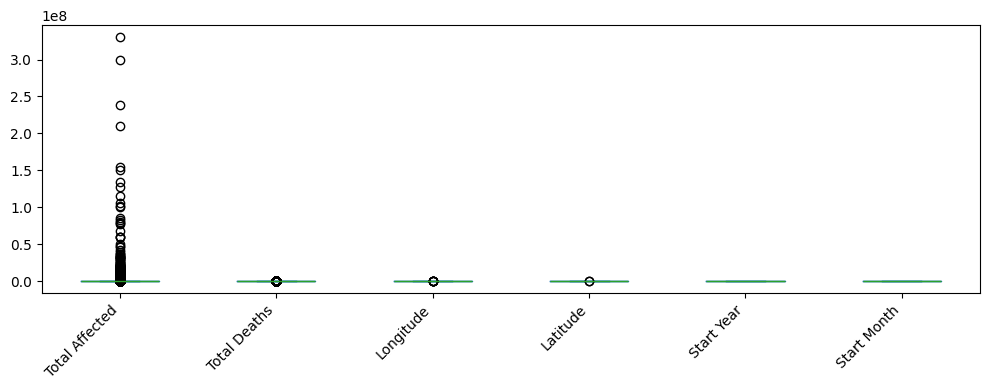

In [39]:
emdat_outlier = outlier_summary(emdat_focus, emdat_relevant_numeric)
if emdat_outlier.empty:
    display(pd.DataFrame({"info": ["Keine numerischen Spalten für Outlier Analyse"]}))
else:
    display(emdat_outlier)
    plot_cols = emdat_outlier.head(6)["column"].tolist()
    if plot_cols:
        emdat_focus[plot_cols].plot(kind="box", figsize=(10, 4))
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

In [40]:
col_name = "Total Affected"

if col_name in emdat_focus.columns:
    s = emdat_focus[col_name].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    top3_outliers_total_affected = (
        emdat_focus[emdat_focus[col_name] > upper]
        .sort_values(col_name, ascending=False)
        .head(3)
    )

    cols_show = [
        c for c in ["Country", "Disaster Type", "Disaster Subtype", "Start Year", "End Year", "Total Affected", "Total Deaths"]
        if c in top3_outliers_total_affected.columns
    ]

    display(pd.DataFrame({"iqr_upper_threshold": [upper], "outlier_count": [int((emdat_focus[col_name] > upper).sum())]}))
    display(top3_outliers_total_affected[cols_show])
else:
    display(pd.DataFrame({"info": [f"Spalte '{col_name}' nicht gefunden"]}))

,iqr_upper_threshold,outlier_count
0,44965.0,2793


,Country,Disaster Type,Disaster Subtype,Start Year,End Year,Total Affected,Total Deaths
16523,India,Drought,Drought,2015,2016,330000000.0,NaN
17624,India,Drought,Drought,2002,2002,300000000.0,NaN
3346,China,Flood,Riverine flood,1998,1998,238973000.0,3656.0


Recherche zeigt, dass die höchsten Outliers Sinn machen.
**Massnahme:** Keine Bereinigung nötig. Wir fügen jedoch für die Outliers einen Flag hinzu, sodass bei einer Analyse allenfalls die Outliers schnell für separate Analyse genutzt werden könnten, bzw ausgeschlossen werden könnten.

## Mittelmeer sea level Daten

In diesem Abschnitt prüfen wir die sea level Daten.


### sea level Überblick
Wir sehen Umfang und einen kleinen Ausschnitt der Variablen.

In [41]:
sea_level_overview = pd.DataFrame(
    {
        "rows": [len(sea_level_df)],
        "cols": [sea_level_df.shape[1]],
    },
    index=["sea_level_df"],
)

display(sea_level_overview)
display(sea_level_focus.head(3))

,rows,cols
sea_level_df,9405,3


,time,MSL_filtered_GIA_corrected_adjusted,trend_MSL_filtered_GIA_corrected_adjusted
0,1999-02-20,3.687602,2.171483
1,1999-02-21,3.684773,2.171927
2,1999-02-22,3.681582,2.172372


Der Überblick zeigt die Abdeckung des sea level Datensatzes.

### sea level Missing values
Wir prüfen Missing values in allen sea level Variablen.

In [42]:
sea_level_missing = missingness_summary(sea_level_focus, sea_level_relevant_cols)
if sea_level_missing.empty:
    display(pd.DataFrame({"info": ["Keine Missing values in sea level Variablen"]}))
else:
    display(sea_level_missing)

,info
0,Keine Missing values in sea level Variablen


Keine NA's in Sea Level Daten.
**Massnahme:** Keine Reinung nötig.

### sea level Duplicates
Wir prüfen Duplicates über alle sea level Spalten.

In [43]:
dup_focus = int(sea_level_focus.duplicated(subset=sea_level_relevant_cols).sum()) if len(sea_level_focus) else 0

dup_df = pd.DataFrame({"scope": ["focus"], "duplicates": [dup_focus]})

display(dup_df)

,scope,duplicates
0,focus,0


Keine Duplicates.
**Massnahme:** Keine Reinigung nötig.

### sea level Time checks
Wir prüfen, ob das time Feld gültig ist und den erwarteten Zeitraum abdeckt.

In [44]:
if "time" in sea_level_focus.columns:
    parsed = pd.to_datetime(sea_level_focus["time"], errors="coerce")
    invalid = max(0, int(parsed.isna().sum() - sea_level_focus["time"].isna().sum()))
    time_df = pd.DataFrame(
        {"invalid": [invalid], "min": [parsed.min()], "max": [parsed.max()]}
    )
    display(time_df)
else:
    display(pd.DataFrame({"info": ["time Spalte fehlt"]}))

,invalid,min,max
0,0,1999-02-20,2024-11-19


**Befund:** Die Zeitreihe ist vollständig valide.

- 0 ungültige Zeitstempel.
- Abdeckung: **1999-02-20 bis 2024-11-19**. Dies entspricht dem erwarteten Zeitraum.

**Massnahme:** Keine Bereinigung notwendig.

### sea level Outliers

,column,outliers,pct
0,MSL_filtered_GIA_corrected_adjusted,0,0.0
1,trend_MSL_filtered_GIA_corrected_adjusted,0,0.0


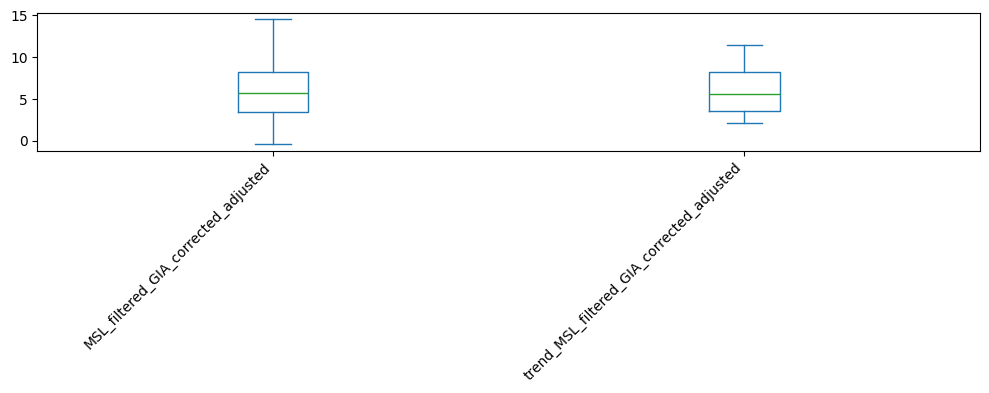

In [45]:
sea_level_outlier = outlier_summary(sea_level_focus, sea_level_value_cols)
if sea_level_outlier.empty:
    display(pd.DataFrame({"info": ["Keine numerischen Spalten für Outlier Analyse"]}))
else:
    display(sea_level_outlier)
    plot_cols = sea_level_outlier.head(6)["column"].tolist()
    if plot_cols:
        sea_level_focus[plot_cols].plot(kind="box", figsize=(10, 4))
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

Keine Outliers.
**Massnahme:** Keine Bereinigung notwendig.

## Temporale Ausrichtung der Datensätze

EMDAT deckt **1991–2024** ab, die Meeresspiegel-Daten aber erst ab **1999-02-20**. Für die spätere Korrelationsanalyse ist nur der gemeinsame Zeitraum 1999–2024 relevant. EMDAT-Einträge vor 1999 können keinem Meeresspiegel-Wert zugeordnet werden.

In [46]:
sea_level_min_year = int(pd.to_datetime(sea_level_focus["time"]).dt.year.min())
emdat_year_range = emdat_focus["Start Year"].dropna()
pre_overlap = int((emdat_year_range < sea_level_min_year).sum())
print(f"EMDAT-Einträge mit Start Year < {sea_level_min_year}: {pre_overlap}")

EMDAT-Einträge mit Start Year < 1999: 3791


**Entscheidung:** EMDAT-Daten werden im Cleaning **nicht** auf 1999+ gefiltert, alle nötigen Filter erfolgen beim Join in einem späteren Notebook.

## Cleaning-Zusammenfassung

| Datensatz | Dimension | Befund | Massnahme |
|---|---|---|---|
| EMDAT | Missing values | Strukturell bedingte Missingness (bis 89.9%); NA bedeutet «nicht erfasst» | Keine Bereinigung |
| EMDAT | Duplikate | Alle `DisNo.` eindeutig; 8 scheinbare Paare sind verschiedene Ereignisse | Keine Bereinigung |
| EMDAT | Outliers | Validiert, extreme Werte entsprechen realen Grosskatastrophen | Keine Bereinigung, wir setzen aber wie erwähnt einen Flag |
| EMDAT | Zeitfelder | Alle Werte in gültigen Bereichen | Keine Bereinigung |
| Sea Level | Missing values | Keine vorhanden | Keine Bereinigung |
| Sea Level | Duplikate | Keine vorhanden | Keine Bereinigung |
| Sea Level | Outliers | Keine vorhanden | Keine Bereinigung |
| Sea Level | Zeitfelder | Vollständig valide, Abdeckung 1999–2024 | Keine Bereinigung |

**Fazit:** An den realen Datensätzen werden keine Cleaning-Operationen vorgenommen.

# Neuer Plan
Wir haben uns nach den erkentnissen entschieden, dass es Sinn macht gewisse Teile der Transformation bereits vor dem Cleaning zu machen.